In [1]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

In [2]:
import cma
import numpy as np
from numbers import Real
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
from sentence_transformers import CrossEncoder
import os
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *
from utils.load import get_segment_imgs
from utils.clipemb import CLIP_emb_from_IMG, CLIP_emb_from_TEXT


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')

SEGMENT_IMGS = get_segment_imgs(SEGMENT_DIR, (WIDTH, HEIGHT))

cpu


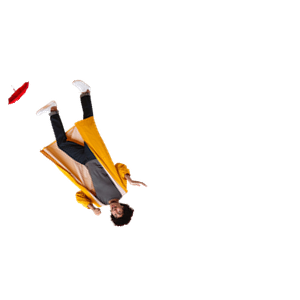

In [4]:
prompt_text = 'the statue of liberty'
prompt_text = 'a person wearing a yellow coat is holding a small red umbrella with his left hand over his head'
prompt_embedding = CLIP_emb_from_TEXT(prompt_text)
prompt_text = 'a person holding an umbrella'
#prompt_embedding = CLIP_emb_from_IMG(SEGMENT_IMGS[prompt_text]['original'])

primitives_selected_names = list(SEGMENT_IMGS[prompt_text].keys())
primitives_selected_names.remove('original') # This is the original image aka the prompt

primitives_selected = [SEGMENT_IMGS[prompt_text][name] for name in primitives_selected_names]

# Initial solution
predictN = 5
N = len(primitives_selected)

x0 = np.ones((N, 5))
# (x, y) positions
x0[:, 0] = 1 / N * np.arange(N) + (1 / N) / 2
x0[:, 0] = 0
x0[:, 1] = 0.25
# s scale
x0[:, 2] = 0.55
x0[1, 2] = 0.1
# r rotation
x0[:, 3] = 0.6
# l layer
x0[:, 4] = x0[:, 0]


# SPECIFIC
if False:
    x0[1, 0] = 0.45
    x0[1, 1] = 0.10
    
    x0[2, 0] = 0.50

    x0[0, 0] = 0.65
    x0[0, 1] = 0.25

    x0[1, 2] = 0.17
    x0[0, 2] = 0.12
rasterize_shapes(primitives_selected, x0, (WIDTH, HEIGHT))


In [119]:
def loss(solution):
    solution = np.clip(solution.reshape(-1, predictN), 0.01, 1)
    img = rasterize_shapes(primitives_selected, solution, (WIDTH, HEIGHT))
    img = Image.alpha_composite(
        Image.new("RGBA", img.size, (54, 108, 176, 255)),  # White background
        img
    ).convert("RGB")

    rasterized_imgs = torch.tensor(np.array(img)).permute(2, 0, 1).to(DEVICE)
    rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) 

    return -torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1).item()

In [92]:
def clip_sol(solution):
    solution[:, 2] = np.clip(solution[:, 2], 0.1, 0.999)
    # Special clip for pos
    #solution[:, 0:1] = np.clip(solution[:, 0:1], 0.2, 0.8)

    # In general clip to maximum 0.9 so that the primitives are all inside the canvas
    return np.clip(solution, 0, 1)

In [107]:
sigma = 0.1
maxiter = 100
popsize = 256

es = cma.CMAEvolutionStrategy(x0.flatten(), sigma, {
    "maxiter": maxiter,
    "popsize": popsize,
    })

(128_w,256)-aCMA-ES (mu_w=66.9,w_1=3%) in dimension 10 (seed=647217, Thu Mar 20 17:55:07 2025)


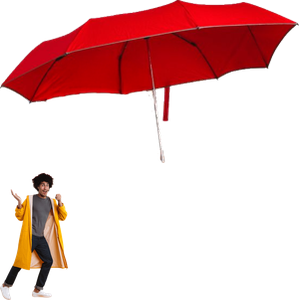

tensor(0.3809)


KeyboardInterrupt: 

In [108]:
report_interval = 10
i = 0
while not es.stop():
    a = time.time()
    solutions = es.ask()

    rasterized_imgs = []

    b = time.time()
    for it, solution in enumerate(solutions):
      # Reshape (one for each primitive)
      solution = solution.reshape(-1, predictN)

      solution = clip_sol(solution)

      img = rasterize_shapes_2(primitives_selected, solution, (WIDTH, HEIGHT))
      rasterized_imgs.append(Image.alpha_composite(
                                #Image.new("RGBA", img.size, (54, 108, 176, 255)),  # White background
                                Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
                                img
                            ).convert("RGB"))

    rasterized_imgs = np.stack(rasterized_imgs, axis=0) # (population_size, 300, 300, 4)
    rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE)
    c = time.time()
    rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)

    losses = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)

    t = time.time()
    print(f"ALL: {b-a}")
    print(f"SOL: {c-b}")
    print(f"EMB: {t-c}")
    print(f'best loss = {losses.max()}')
    print(f'avg loss = {np.average(losses)}')
    if i % 1 == 0:
      print(f'loss migliore = {losses.max()}')
      best = solutions[losses.argmax()]
      img = rasterized_imgs[losses.argmax()].cpu().numpy()
      img = np.transpose(img, (1,2,0))
      img_pil = Image.fromarray(img.astype('uint8'), 'RGB')
      #img_pil.save(path.join(RESULTS_DIR, f'img{i}.png'))
      clear_output(wait=True)  # Clear previous output
      display(img_pil)         # Display the new image

    print(losses.max())
    # Minus because we want to maximize the similarity
    es.tell(solutions, [-l.item() for l in losses])
    i += 1
  


In [102]:
es.best.x.reshape(-1, predictN)[:, 2]

array([0.51988795, 0.73975716])

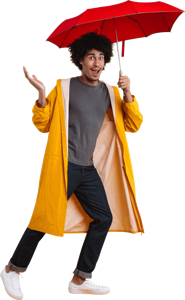

In [124]:
display(SEGMENT_IMGS[prompt_text]['original'])